In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

# Aperçu rapide

In [2]:
# Charger les données
df = pd.read_csv("../data/01_raw/Churn_Modelling.csv")

# Aperçu rapide
print(f"Shape : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nTypes :\n{df.dtypes}")

Shape : (10000, 14)

Colonnes : ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Types :
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


# Distribution

Exited
0    7963
1    2037
Name: count, dtype: int64


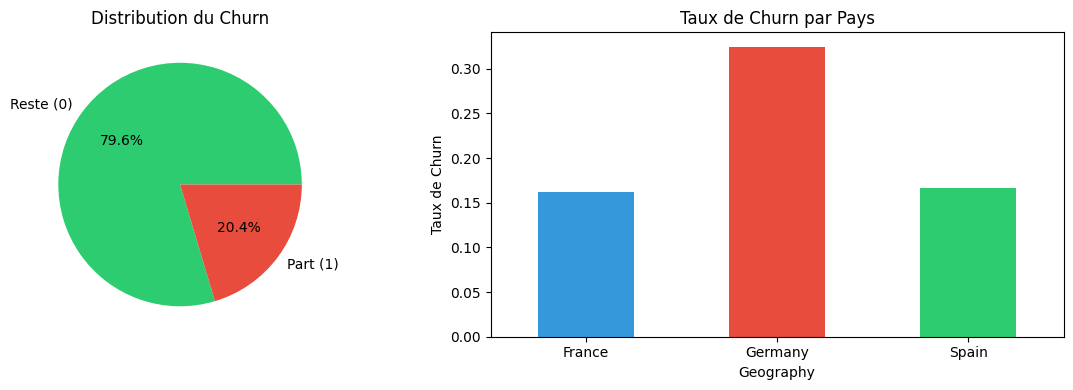

In [4]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 — Pie chart
churn_counts = df['Exited'].value_counts()
print(churn_counts)
axes[0].pie(churn_counts, 
            labels=['Reste (0)', 'Part (1)'], 
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution du Churn')

# Graphique 2 — Par géographie
df.groupby('Geography')['Exited'].mean().plot(
    kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71']
)
axes[1].set_title('Taux de Churn par Pays')
axes[1].set_ylabel('Taux de Churn')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Analyse des variables numériques

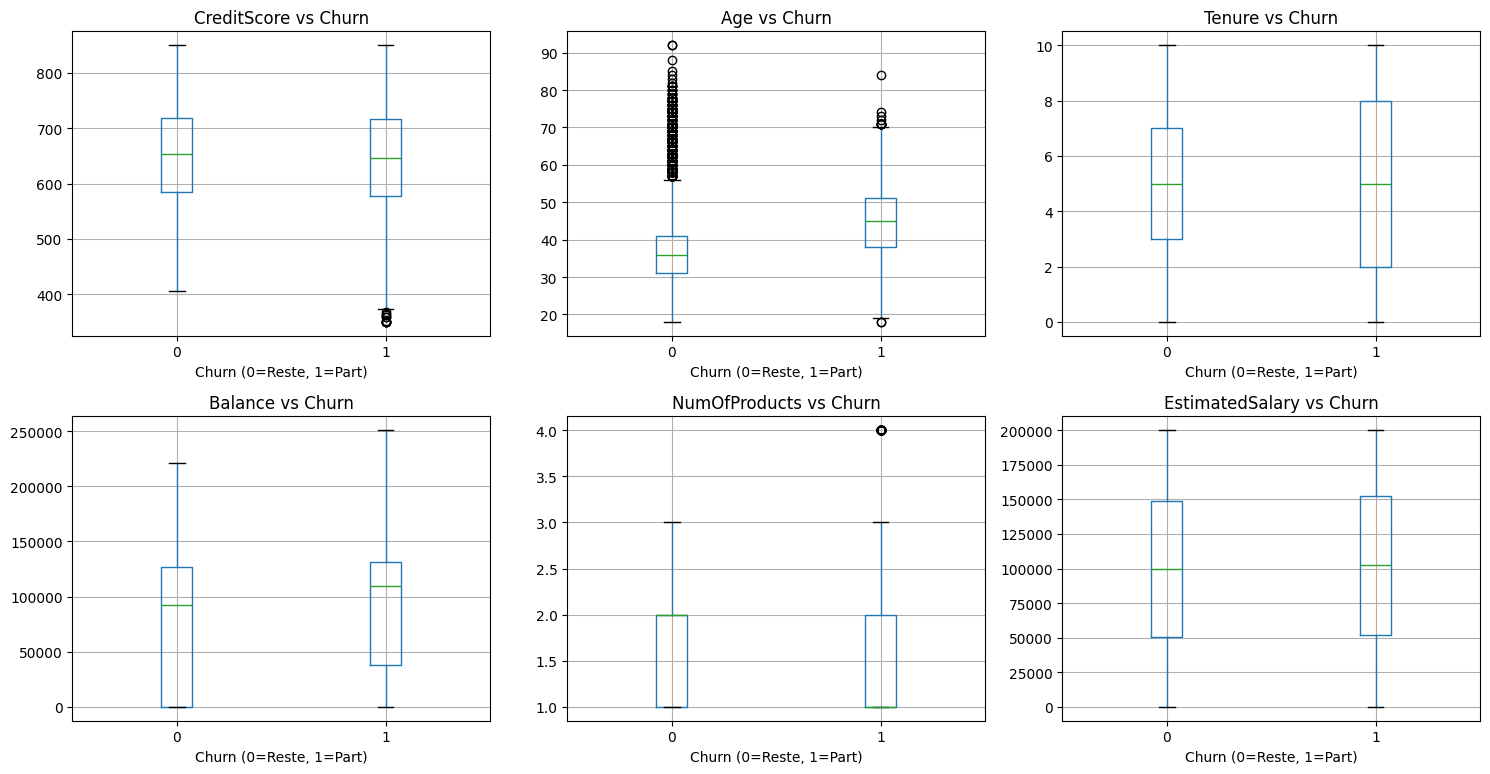

In [5]:
# Variables numériques vs Churn
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

variables_num = ['CreditScore', 'Age', 'Tenure', 
                 'Balance', 'NumOfProducts', 'EstimatedSalary']

for i, var in enumerate(variables_num):
    df.boxplot(column=var, by='Exited', ax=axes[i])
    axes[i].set_title(f'{var} vs Churn')
    axes[i].set_xlabel('Churn (0=Reste, 1=Part)')

plt.suptitle('')
plt.tight_layout()
plt.show()

##### Resume 

Age       → churners plus âgés (≈45 ans vs ≈35 ans)

Balance   → churners ont plus d'argent

Geography → Allemagne churn le plus

Churn     → déséquilibre 80/20

# Corrélation et heatmap

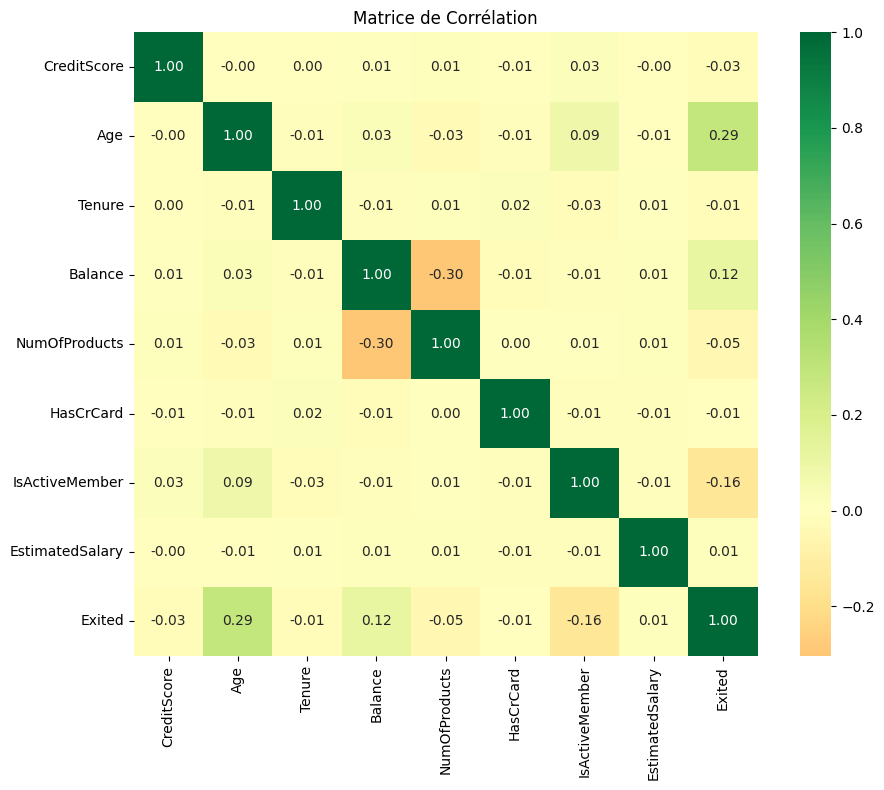

In [6]:
# Heatmap de corrélation
plt.figure(figsize=(10, 8))

# Garder seulement les variables numériques
vars_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 
            'NumOfProducts', 'HasCrCard', 
            'IsActiveMember', 'EstimatedSalary', 'Exited']

corr = df[vars_num].corr()

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True)

plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()